# Time-resolved energies and influence spectrum

## Table of contents
<a name="toc"></a>
1. [Importing needed libraries](#import)
2. [Overview of required files](#required_files)
3. [Energy vs time](#ene_time)
4. [Influence spectrum](#inf_spec)
5. [Spectral density](#5)
   
### A. Learning objectives

* To be able to plot the computed excited states energies vs time
* To be able to compute and plot the influence spectrum

### B. Use cases


* [Energy vs time](#ene_time)
* [Influence spectrum](#inf_spec)
* [Spectral density](#5)


### C. Functions

- `libra_py`
  - `influence_spectrum`
    - [`recipe1`](#inf_spec)
  - `packages`
    - `cp2k`
      - `methods`
        - [`extract_energies_sparse`](#ene_time)
  - `units`
    - `au2ev`

## 1. Importing needed libraries <a name="import"></a>
[Back to TOC](#toc)

Here, we import `numpy`, `matplotlib.pyplot`, `CP2K_methods`, and `influence_spectrum`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from liblibra_core import *
import libra_py.packages.cp2k.methods as CP2K_methods
from libra_py import units, influence_spectrum

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 2. Overview of required files <a name="required_files"></a>
[Back to TOC](#toc)

All the energy files are in this folder:

* `data/res-mb-sd-DFT`

## 3. Energy vs time <a name="ene_time"></a>
[Back to TOC](#toc)

Here, we will plot the energies of the many-body and single-particle excitation bases

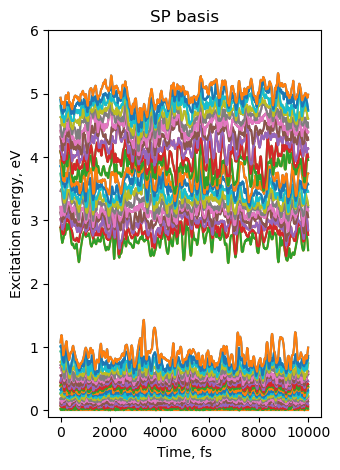

In [2]:
%matplotlib inline
params = {"path_to_energy_files": "/vscratch/grp-cyberwksp21/utkarsh/Tutorials_Libra/11_program_specific_methods/3_cp2k_methods/3_time_resolved_energies/res", "dt": 10.0, 
          "prefix": "E", "suffix": "", "istep": 0, "fstep": 1000}

titles = ['SP basis', 'MB basis']
plt.figure()
for c, basis in enumerate(['ks']):
    plt.subplot(1,2,c+1)
    params.update({"prefix": F"E_{basis}_"})
    md_time, energies = CP2K_methods.extract_energies_sparse(params)
    energies = energies * units.au2ev
    for i in range(energies.shape[1]):
        plt.plot(md_time, energies[:,i]-energies[:,0])
    
    plt.title(titles[c])
    plt.ylabel('Excitation energy, eV')
    plt.xlabel('Time, fs')
    plt.ylim(-0.1, 6)

plt.tight_layout()
# Save figure
plt.savefig("E_vs_t.png", dpi=600, bbox_inches="tight")

## 4. Influence spectrum <a name="inf_spec"></a>
[Back to TOC](#toc)

### 4.1. Theoretical Background

#### A. Energy-gap fluctuations

Assume a system observable (often an electronic energy gap) evolves in time:

$$
\Delta E(t)
$$

Define fluctuations around the mean:

$$
\delta E(t)=\Delta E(t)-\langle\Delta E\rangle
$$

where

$$
\langle\Delta E\rangle
=
\frac{1}{T}\int_0^T\Delta E(t)\,dt
$$

These fluctuations encode how the environment perturbs the quantum subsystem.


#### B. Time-domain bath correlation function

The central quantity is the autocorrelation function:

$$
C(t)
=
\langle
\delta E(0)\delta E(t)
\rangle
$$

Properties:

- measures memory of environmental fluctuations
- large correlation time → non-Markovian bath
- short correlation time → Markovian bath

Typical behavior:

$$
C(t)\rightarrow0
\qquad
(t\rightarrow\infty)
$$

#### C. Influence spectrum (noise spectrum)

The **influence spectrum** is the Fourier transform of the correlation function:

$$
I(\omega)
=
\int_{-\infty}^{\infty}
C(t)e^{i\omega t}\,dt
$$

Since equilibrium correlation functions satisfy:

$$
C(t)=C(-t)
$$

the transform reduces to:

$$
I(\omega)
=
2
\int_0^\infty
C(t)\cos(\omega t)\,dt
$$

Interpretation:

- tells **how strongly fluctuations occur at frequency** ( $\omega$ )
- describes environmental noise distribution
- purely classical quantity if derived from classical trajectories

Units:

$$
[I(\omega)]
=
[E]^2\cdot [t]
$$



### 4.2. Practical Part

In order to compute the influence spectrum for the energy gap fluctuations between two states, `i` and `j`. The parameters that need to be passed to the function `influence_spectrum.recipe1` are as follows:

`data`: A list of `MATRIX(ndof, 1)` objects i.e. a sequence of real-valued ndof-dimensional vectors

`dt`: Time step in fs units
    
`wspan`: The window of frequencies for the Fourier transform with units cm$^{-1}$

`dw`: The grid points spacing in the frequency domain with units of cm$^{-1}$

`do_output`: Whether we print out the data the results into files

`acf_filename`: The name of the file where to print the ACF
    
`spectrum_filename`: The name of the file where to print the spectrum 

`do_center`: A flag controlling whether to center data (=`True`) or not (=`False`). Centering means we subtract the average value (over all the data points) from all the data points - this way, we convert values into their fluctuations 

`acf_type`: selector of the convention to to compute ACF:
```
   * 0 : the chemist convention,  (1/(N-h)) Sum_{t=1,N-h} (Y[t]*Y[t+h]) [ default ]
   * 1 : the statistician convention, (1/N) Sum_{t=1,N-h} (Y[t]*Y[t+h])
```

`data_type`: What is the format of the data?
```
        * 0 : list of MATRIX(ndof, 1) [ default ]
        * 1 : list of VECTOR
```

The `recipe1` function returns a tuple of (T, norm_acf, raw_acf, W, J, J2), where:

`T`: List with time axis in `fs` units

`norm_acf`: List with normalized ACF

`raw_acf`: List with un-normalized ACF

`W`: List with frequencies axis with units $cm^{-1}$

`J`: List with amplitudes of Fourier transform

`J2`: List with values of $(1/2\pi)|J|^2$

Select two states of interest to compute the influence spectrum for their energy gap fluctuations. Here we comute that for the ground state, `i=0`, and the first excited state, `j=1` and then plot the spectrum.

In [ ]:
# For computing influence spectra
params_inf_cpec = {"dt": 10.0, "wspan": 5000.0, "dw": 1.0, "do_output": False,
          "do_center": True, "acf_type": 1, "data_type": 0}
# ==========
# Selecting the two states we want to compute the influence spectra for
i = 0; j = 1
# ========== Computing the autocorrelation function and the influence spectra
data_ij = []
for step in range(energies.shape[0]):
    x = MATRIX(1,1)
    if i<j:
        gap = energies[step,j]-energies[step,i]
    else:
        gap = energies[step,i]-energies[step,j]
    x.set(0,0, gap)
    data_ij.append(x)
Tij, ACFij, uACFij, Wij, Jij, J2ij = influence_spectrum.recipe1(data_ij, params_inf_cpec)

plt.plot(Wij, J2ij)
plt.xlabel('Frequency, cm$^{-1}$')
plt.ylabel('Intensity, a.u.')
plt.yticks([])
plt.title(F'Influence spectrum, states: {i},{j}')
plt.tight_layout()

In [ ]:
# For computing influence spectra
params_inf_cpec = {"dt": 10.0, "wspan": 5000.0, "dw": 1.0, "do_output": False,
          "do_center": True, "acf_type": 1, "data_type": 0}
# ==========
# Selecting the two states we want to compute the influence spectra for
i = 0; j = 2
# ========== Computing the autocorrelation function and the influence spectra
data_ij = []
for step in range(energies.shape[0]):
    x = MATRIX(1,1)
    if i<j:
        gap = energies[step,j]-energies[step,i]
    else:
        gap = energies[step,i]-energies[step,j]
    x.set(0,0, gap)
    data_ij.append(x)
Tij, ACFij, uACFij, Wij, Jij, J2ij = influence_spectrum.recipe1(data_ij, params_inf_cpec)

plt.plot(Wij, J2ij)
plt.xlabel('Frequency, cm$^{-1}$')
plt.ylabel('Intensity, a.u.')
plt.yticks([])
plt.title(F'Influence spectrum, states: {i},{j}')
plt.tight_layout()

In [ ]:
# For computing influence spectra
params_inf_cpec = {"dt": 10.0, "wspan": 5000.0, "dw": 1.0, "do_output": False,
          "do_center": True, "acf_type": 1, "data_type": 0}
# ==========
# Selecting the two states we want to compute the influence spectra for
i = 0; j = 3
# ========== Computing the autocorrelation function and the influence spectra
data_ij = []
for step in range(energies.shape[0]):
    x = MATRIX(1,1)
    if i<j:
        gap = energies[step,j]-energies[step,i]
    else:
        gap = energies[step,i]-energies[step,j]
    x.set(0,0, gap)
    data_ij.append(x)
Tij, ACFij, uACFij, Wij, Jij, J2ij = influence_spectrum.recipe1(data_ij, params_inf_cpec)

plt.plot(Wij, J2ij)
plt.xlabel('Frequency, cm$^{-1}$')
plt.ylabel('Intensity, a.u.')
plt.yticks([])
plt.title(F'Influence spectrum, states: {i},{j}')
plt.tight_layout()

In [ ]:
# For computing influence spectra
params_inf_cpec = {"dt": 10.0, "wspan": 5000.0, "dw": 1.0, "do_output": False,
          "do_center": True, "acf_type": 1, "data_type": 0}
# ==========
# Selecting the two states we want to compute the influence spectra for
i = 0; j = 4
# ========== Computing the autocorrelation function and the influence spectra
data_ij = []
for step in range(energies.shape[0]):
    x = MATRIX(1,1)
    if i<j:
        gap = energies[step,j]-energies[step,i]
    else:
        gap = energies[step,i]-energies[step,j]
    x.set(0,0, gap)
    data_ij.append(x)
Tij, ACFij, uACFij, Wij, Jij, J2ij = influence_spectrum.recipe1(data_ij, params_inf_cpec)

plt.plot(Wij, J2ij)
plt.xlabel('Frequency, cm$^{-1}$')
plt.ylabel('Intensity, a.u.')
plt.yticks([])
plt.title(F'Influence spectrum, states: {i},{j}')
plt.tight_layout()

## 5. Spectral density <a name="5"></a>
[Back to TOC](#toc)

### 5.1. Theoretical Background


#### A. Spectral density

The **spectral density** converts fluctuation strength into effective system–bath coupling.

For a harmonic bath:

$$
J(\omega)
=
\sum_k
g_k^2
\delta(\omega-\omega_k)
$$

where:

- ($g_k$): coupling strength
- ($\omega_k$): bath mode frequency

Continuous limit:

$$
J(\omega)
=
g^2(\omega)\rho(\omega)
$$

where:

- (g($\omega$)): frequency-dependent coupling
- ($\rho(\omega)$): density of bath states


#### B. Relation between influence spectrum and spectral density

For classical energy-gap fluctuations:

$$
J(\omega)
\propto
\beta\omega I(\omega)
$$

or more explicitly:

$$
J(\omega)
=
\frac{\beta\omega}{2}
I(\omega)
$$

with

$$
\beta
=
\frac{1}{k_B T}
$$

Equivalent expression:

$$
J(\omega)
=
\beta\omega
\int_0^\infty
C(t)\cos(\omega t)\,dt
$$

The prefactor imposes approximate quantum detailed balance.

### 5.2. Practical Part

In [ ]:
w = np.array(Wij)
J = np.array(Jij)

In [ ]:
plt.plot(w, J*w)
plt.xlabel('Frequency, cm$^{-1}$')
plt.ylabel('Intensity, a.u.')
plt.yticks([])
plt.title(F'Spectral density, states: {i},{j}')
plt.tight_layout()

## 6. Reorganization energy<a name="6"></a>
[Back to TOC](#toc)

### 6.1. Theoretical Background

Spectral density determines total environmental coupling:

$$
\lambda
=
\int_0^\infty
\frac{J(\omega)}{\omega}
\,d\omega
$$

(or conventionally with an additional \(1/\pi\))

Interpretation:

- total relaxation energy of the bath
- important in Marcus theory, Redfield, HEOM, spin-boson models


## 7. Modern script<a name="7"></a>
[Back to TOC](#toc)

### 7.1. Gap

In [ ]:
gap = energies[:,1]-energies[:,0]
print(gap)
plt.plot(gap)

### 7.2. Gap fluctuation

In [ ]:
dE = gap - np.mean(gap)
print(dE)
plt.plot(dE)

### 7.3. Autocorrelation function of the gap fluctuation

In [ ]:
C = np.correlate(dE, dE, mode='full')
C = C[len(C)//2:]
C /= np.arange(len(dE),0,-1)
print(C)
print(C.shape)
plt.plot(C)

### 7.4. Frequency plotting

In [ ]:
dt = 1.0 * units.fs2au # a.u.

omega = 2*np.pi*np.fft.rfftfreq(len(C), dt) * units.au2wavn #

In [ ]:
T = 300.0
kB = units.kB
beta = 1.0/(kB*T)
J = beta * omega * np.real(np.fft.rfft(C))*dt

In [ ]:
plt.plot(omega, J)

plt.xlim(0, 10000)   # show only 0–4000 cm^-1

plt.xlabel("Frequency (cm$^{-1}$)")
plt.ylabel("J($\omega$)")
plt.show()